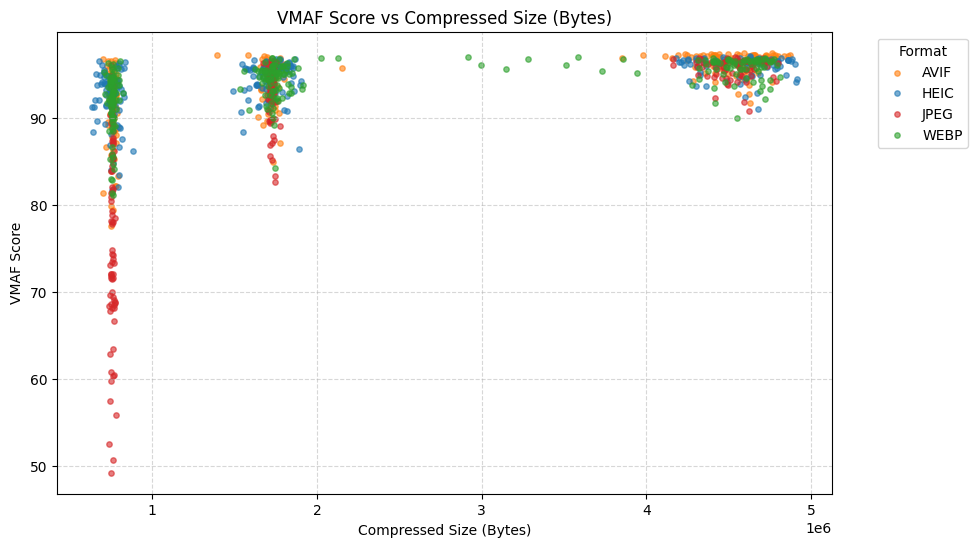

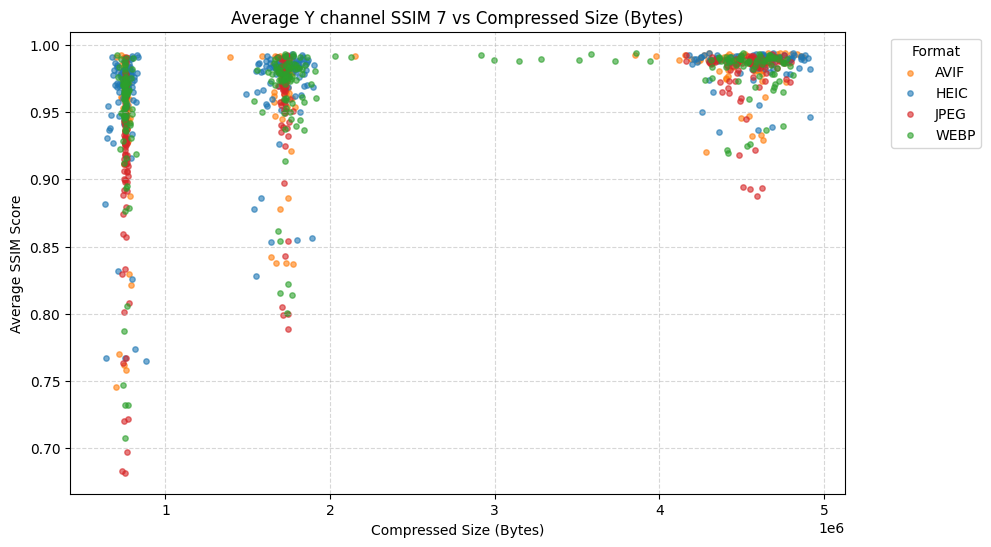

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Load data
df = pd.read_csv('unified_results_complete.csv')
df = df[df['Category'] != 'Document']

# Calculate average SSIM across all 9 SSIM columns
##ssim_cols = [col for col in df.columns if 'SSIM' in col]
##df['Average_SSIM'] = df[ssim_cols].mean(axis=1)

# Set the requested color mapping

color_map = {
    'HEIC': '#1f77b4',
    'JPEG': '#d62728',
    'WEBP': '#2ca02c',
    'AVIF': '#ff7f0e'
}

# Plot 1: VMAF vs Size
plt.figure(figsize=(10, 6))
for fmt in df['Format'].unique():
    subset = df[df['Format'] == fmt]
    plt.scatter(subset['Compressed_Size_Bytes'], subset['VMAF'], 
                c=color_map.get(fmt, 'black'), label=fmt, alpha=0.6, s=15)

plt.title('VMAF Score vs Compressed Size (Bytes)')
plt.xlabel('Compressed Size (Bytes)')
plt.ylabel('VMAF Score')
plt.legend(title='Format', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
## plt.savefig('vmaf_vs_size.png', bbox_inches='tight')
plt.show()
plt.close()

# Plot 2: Average SSIM vs Size
plt.figure(figsize=(10, 6))
for fmt in df['Format'].unique():
    subset = df[df['Format'] == fmt]
    plt.scatter(subset['Compressed_Size_Bytes'], subset['Y_SSIM_w7'], 
                c=color_map.get(fmt, 'black'), label=fmt, alpha=0.6, s=15)

plt.title('Average Y channel SSIM 7 vs Compressed Size (Bytes)')
plt.xlabel('Compressed Size (Bytes)')
plt.ylabel('Average SSIM Score')
plt.legend(title='Format', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
## plt.savefig('ssim_vs_size.png', bbox_inches='tight')
plt.show()
plt.close()

In [2]:
df.head()

,Original_Image,Format,Quality_Level,Category,Encoding_Time_sec,VMAF,Compressed_Size_Bytes,Baseline_PNG_Bytes,Storage_Saved_%,Y_MSE,...,Cb_MSE,Cb_PSNR,Cb_SSIM_w7,Cb_SSIM_w11,Cb_SSIM_w21,Cr_MSE,Cr_PSNR,Cr_SSIM_w7,Cr_SSIM_w11,Cr_SSIM_w21
60,DSC00001,AVIF,1,Smooth,1.114391,95.982362,728164.0,17725598.0,95.89,0.765299,...,0.900785,48.584591,0.993287,0.992761,0.992183,0.960854,48.304231,0.991298,0.990692,0.990112
61,DSC00001,AVIF,2,Smooth,1.644167,95.731346,2149788.0,17725598.0,87.87,0.724726,...,0.859918,48.786236,0.993164,0.992721,0.992311,0.914307,48.519885,0.991185,0.990703,0.990316
62,DSC00001,AVIF,3,Smooth,2.197227,96.637201,4713166.0,17725598.0,73.41,0.572141,...,0.824004,48.971509,0.993534,0.993242,0.992950,0.859345,48.789130,0.991841,0.991548,0.991302
63,DSC00001,HEIC,1,Smooth,4.019553,95.813826,828938.0,17725598.0,95.32,0.732850,...,0.850838,48.832333,0.992173,0.991666,0.991122,0.913396,48.524213,0.990464,0.989865,0.989282
64,DSC00001,HEIC,2,Smooth,6.354328,96.003793,1771970.0,17725598.0,90.00,0.646678,...,0.783387,49.191042,0.992506,0.992067,0.991600,0.834912,48.914397,0.990815,0.990323,0.989847


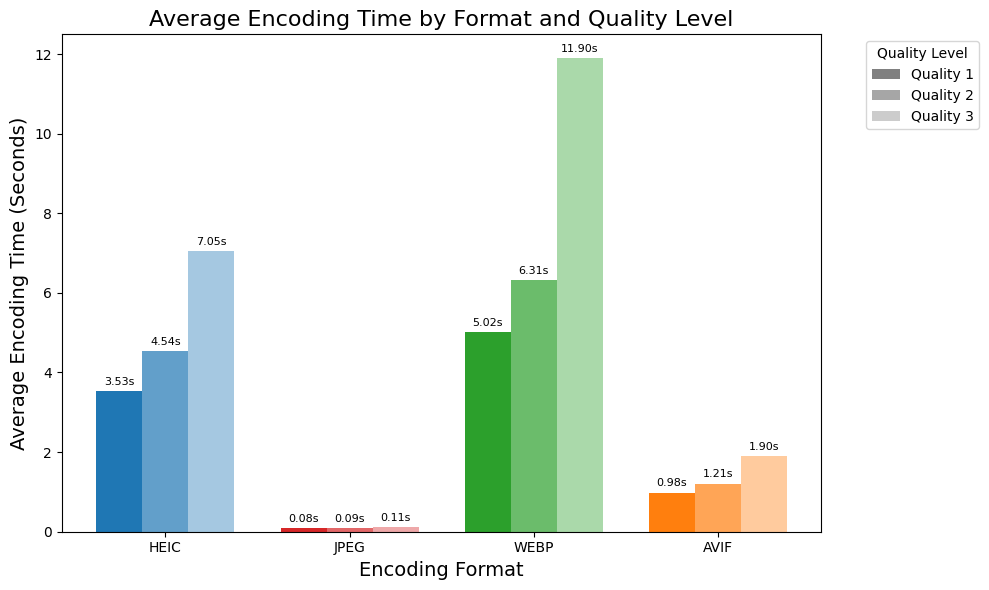

In [3]:
## Calculate average encoding time for each Format at each Quality Level
avg_time_df = df.groupby(['Quality_Level', 'Format'])['Encoding_Time_sec'].mean().reset_index()

# 4. Get the unique quality levels
quality_levels = sorted(df['Quality_Level'].unique())

# Define the order of formats to ensure consistency across charts
format_order = ['HEIC', 'JPEG', 'WEBP', 'AVIF']

# 5. Create a single independent figure
plt.figure(figsize=(10, 6))

# X-axis positioning
x = np.arange(len(format_order))
width = 0.25

q1_vals, q2_vals, q3_vals, colors = [], [], [], []

# Extract times and colors in the specified order for all three quality levels
for fmt in format_order:
    fmt_data = avg_time_df[avg_time_df['Format'] == fmt]
    
    # Extract data dynamically for the 3 quality levels
    q1_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[0]]['Encoding_Time_sec'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[0]].empty else 0)
    q2_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[1]]['Encoding_Time_sec'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[1]].empty else 0)
    q3_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[2]]['Encoding_Time_sec'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[2]].empty else 0)
    
    colors.append(color_map.get(fmt, 'gray'))

# Create the triple gradient bar chart (same color, different transparency)
bars_q1 = plt.bar(x - width, q1_vals, width, color=colors, alpha=1.0)
bars_q2 = plt.bar(x, q2_vals, width, color=colors, alpha=0.7)
bars_q3 = plt.bar(x + width, q3_vals, width, color=colors, alpha=0.4)

# Formatting the plot
plt.title('Average Encoding Time by Format and Quality Level', fontsize=16)
plt.xlabel('Encoding Format', fontsize=14)
plt.ylabel('Average Encoding Time (Seconds)', fontsize=14)
plt.xticks(x, format_order)

# Add value labels on top of each bar for readability
for bars in [bars_q1, bars_q2, bars_q3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.annotate(f'{height:.2f}s',
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom', fontsize=8)

# Custom legend for the Quality Levels placed OUTSIDE the plot
legend_elements = [
    Patch(facecolor='gray', alpha=1.0, label=f'Quality {quality_levels[0]}'),
    Patch(facecolor='gray', alpha=0.7, label=f'Quality {quality_levels[1]}'),
    Patch(facecolor='gray', alpha=0.4, label=f'Quality {quality_levels[2]}')
]
plt.legend(handles=legend_elements, title='Quality Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent clipping (especially for the outside legend)
plt.tight_layout()

# Save/Show the single figure
plt.show()
plt.close()

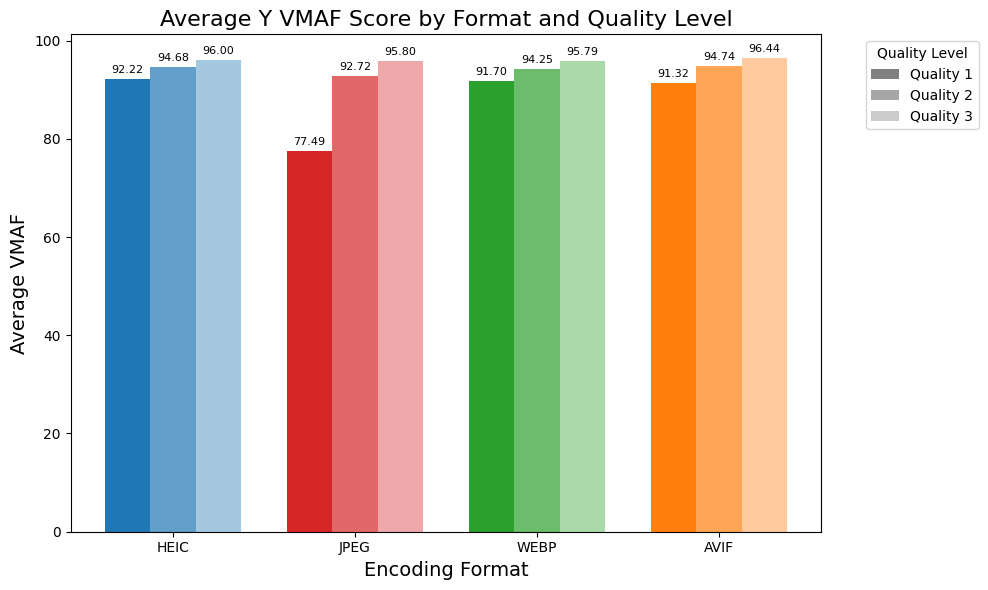

In [4]:
import numpy as np
from matplotlib.patches import Patch

## Calculate average VMAF for each Format at each Quality Level
avg_vmaf_df = df.groupby(['Quality_Level', 'Format'])['VMAF'].mean().reset_index()

# 4. Get the unique quality levels
quality_levels = sorted(df['Quality_Level'].unique())

# Define the order of formats to ensure consistency across charts
format_order = ['HEIC', 'JPEG', 'WEBP', 'AVIF']

# 5. Create a single independent figure
plt.figure(figsize=(10, 6))

# X-axis positioning
x = np.arange(len(format_order))
width = 0.25

q1_vals, q2_vals, q3_vals, colors = [], [], [], []

# Extract VMAF and colors in the specified order for all three quality levels
for fmt in format_order:
    fmt_data = avg_vmaf_df[avg_vmaf_df['Format'] == fmt]
    
    # Extract data dynamically for the 3 quality levels
    q1_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[0]]['VMAF'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[0]].empty else 0)
    q2_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[1]]['VMAF'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[1]].empty else 0)
    q3_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[2]]['VMAF'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[2]].empty else 0)
    
    colors.append(color_map.get(fmt, 'gray'))

# Create the triple gradient bar chart (same color, different transparency)
bars_q1 = plt.bar(x - width, q1_vals, width, color=colors, alpha=1.0)
bars_q2 = plt.bar(x, q2_vals, width, color=colors, alpha=0.7)
bars_q3 = plt.bar(x + width, q3_vals, width, color=colors, alpha=0.4)

# Formatting the plot
plt.title('Average Y VMAF Score by Format and Quality Level', fontsize=16)
plt.xlabel('Encoding Format', fontsize=14)
plt.ylabel('Average VMAF', fontsize=14)
plt.xticks(x, format_order)

# Add value labels on top of each bar for readability
for bars in [bars_q1, bars_q2, bars_q3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.annotate(f'{height:.2f}',
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom', fontsize=8)

# Custom legend for the Quality Levels placed OUTSIDE the plot
legend_elements = [
    Patch(facecolor='gray', alpha=1.0, label=f'Quality {quality_levels[0]}'),
    Patch(facecolor='gray', alpha=0.7, label=f'Quality {quality_levels[1]}'),
    Patch(facecolor='gray', alpha=0.4, label=f'Quality {quality_levels[2]}')
]
plt.legend(handles=legend_elements, title='Quality Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent clipping (especially for the outside legend)
plt.tight_layout()

# Save/Show the individual figure
plt.show()

# Clear the current figure
plt.close()

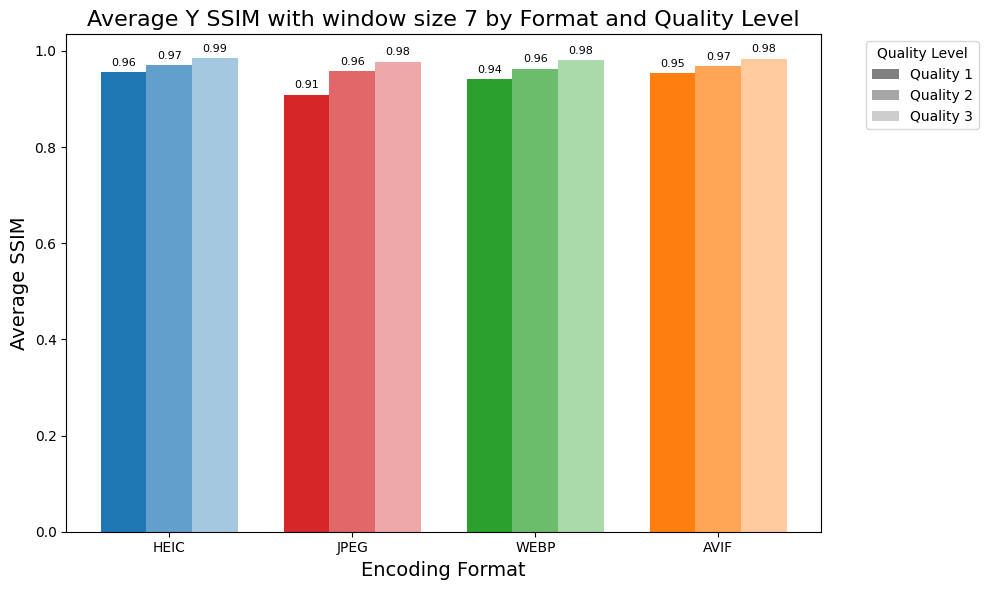

In [5]:
import numpy as np
from matplotlib.patches import Patch

## Calculate average Y_SSIM_w7 for each Format at each Quality Level
avg_ssim_df = df.groupby(['Quality_Level', 'Format'])['Y_SSIM_w7'].mean().reset_index()

# 4. Get the unique quality levels
quality_levels = sorted(df['Quality_Level'].unique())

# Define the order of formats to ensure consistency across charts
format_order = ['HEIC', 'JPEG', 'WEBP', 'AVIF']

# 5. Create a single independent figure
plt.figure(figsize=(10, 6))

# X-axis positioning
x = np.arange(len(format_order))
width = 0.25

q1_vals, q2_vals, q3_vals, colors = [], [], [], []

# Extract SSIM and colors in the specified order for all three quality levels
for fmt in format_order:
    fmt_data = avg_ssim_df[avg_ssim_df['Format'] == fmt]
    
    # Extract data dynamically for the 3 quality levels
    q1_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[0]]['Y_SSIM_w7'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[0]].empty else 0)
    q2_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[1]]['Y_SSIM_w7'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[1]].empty else 0)
    q3_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[2]]['Y_SSIM_w7'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[2]].empty else 0)
    
    colors.append(color_map.get(fmt, 'gray'))

# Create the triple gradient bar chart (same color, different transparency)
bars_q1 = plt.bar(x - width, q1_vals, width, color=colors, alpha=1.0)
bars_q2 = plt.bar(x, q2_vals, width, color=colors, alpha=0.7)
bars_q3 = plt.bar(x + width, q3_vals, width, color=colors, alpha=0.4)

# Formatting the plot
plt.title('Average Y SSIM with window size 7 by Format and Quality Level', fontsize=16)
plt.xlabel('Encoding Format', fontsize=14)
plt.ylabel('Average SSIM', fontsize=14)
plt.xticks(x, format_order)

# Add value labels on top of each bar for readability
for bars in [bars_q1, bars_q2, bars_q3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.annotate(f'{height:.2f}',
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom', fontsize=8)

# Custom legend for the Quality Levels placed OUTSIDE the plot
legend_elements = [
    Patch(facecolor='gray', alpha=1.0, label=f'Quality {quality_levels[0]}'),
    Patch(facecolor='gray', alpha=0.7, label=f'Quality {quality_levels[1]}'),
    Patch(facecolor='gray', alpha=0.4, label=f'Quality {quality_levels[2]}')
]
plt.legend(handles=legend_elements, title='Quality Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent clipping (especially for the outside legend)
plt.tight_layout()

# Save/Show the single figure
plt.show()

# Clear the current figure
plt.close()

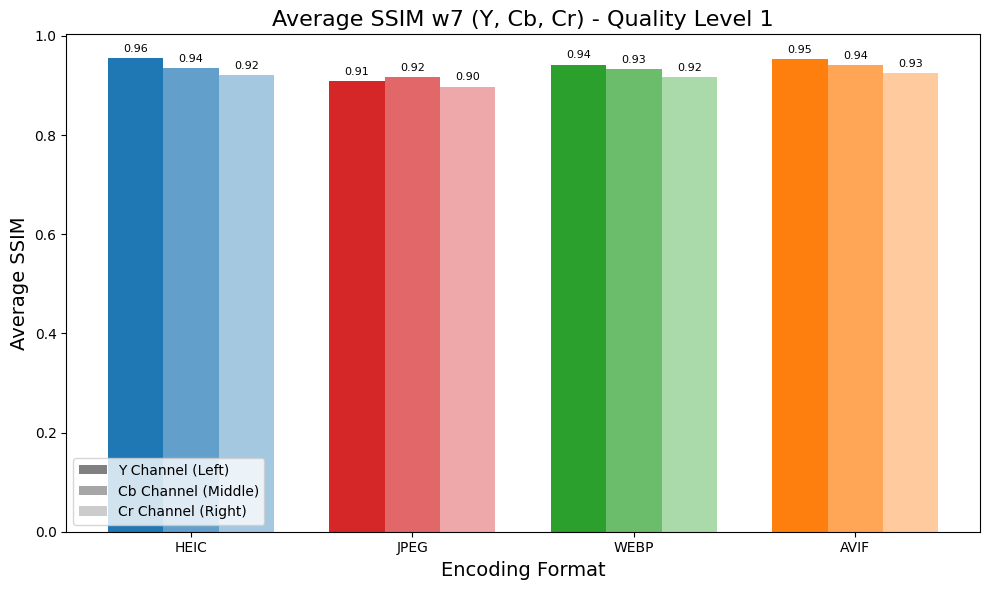

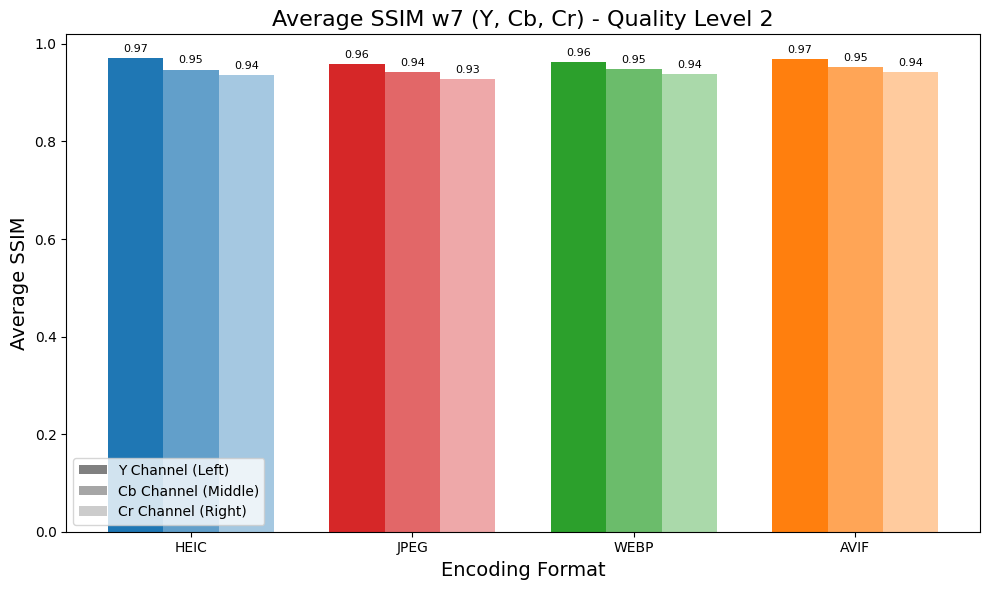

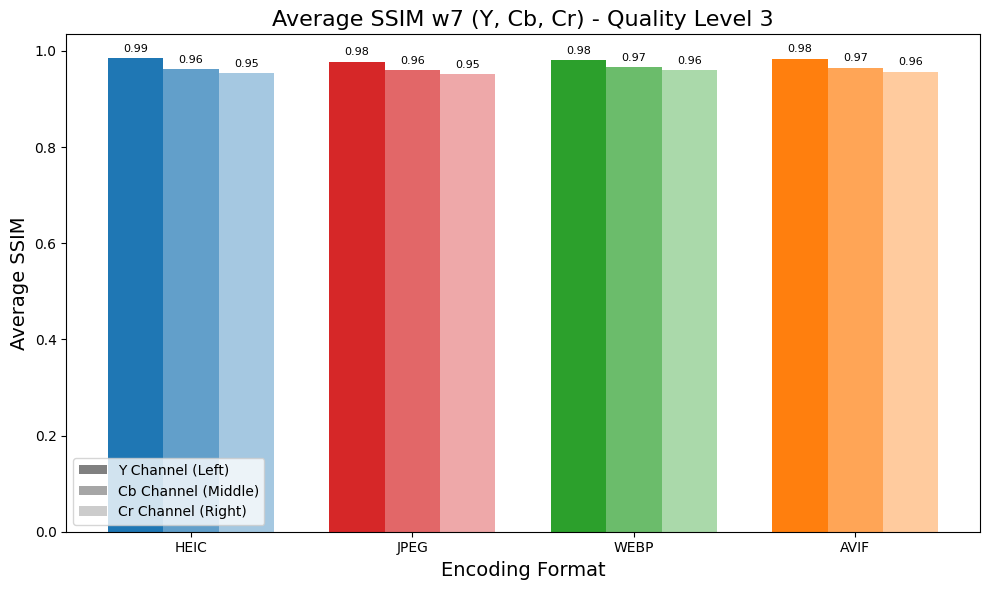

In [6]:
# Define standard configurations
format_order = ['HEIC', 'JPEG', 'WEBP', 'AVIF']

# 1. Calculate average for all three channels at once
avg_ssim_df = df.groupby(['Quality_Level', 'Format'])[['Y_SSIM_w7', 'Cb_SSIM_w7', 'Cr_SSIM_w7']].mean().reset_index()
quality_levels = sorted(avg_ssim_df['Quality_Level'].dropna().unique())

# 2. Create plots loop
for q_level in quality_levels:
    plt.figure(figsize=(10, 6))
    subset = avg_ssim_df[avg_ssim_df['Quality_Level'] == q_level]
    
    # X-axis positioning
    x = np.arange(len(format_order))  # Base locations for the formats
    width = 0.25  # Thinner bars
    
    y_vals, cb_vals, cr_vals, colors = [], [], [], []
    
    # Extract data in the correct format order
    for fmt in format_order:
        fmt_data = subset[subset['Format'] == fmt]
        if not fmt_data.empty:
            y_vals.append(fmt_data['Y_SSIM_w7'].values[0])
            cb_vals.append(fmt_data['Cb_SSIM_w7'].values[0])
            cr_vals.append(fmt_data['Cr_SSIM_w7'].values[0])
            colors.append(color_map.get(fmt, 'gray'))
        else:
            # Fallbacks if a format is missing
            y_vals.append(0); cb_vals.append(0); cr_vals.append(0); colors.append('gray')

    # 3. Plot the 3 thinner bars next to each other
    # We use slightly different alpha (transparency) so they stay the same color but are distinguishable
    bars_y  = plt.bar(x - width, y_vals, width, color=colors, label='Y Channel')
    bars_cb = plt.bar(x, cb_vals, width, color=colors, alpha=0.7, label='Cb Channel')
    bars_cr = plt.bar(x + width, cr_vals, width, color=colors, alpha=0.4, label='Cr Channel')

    # 4. Add text annotations on top
    for bars in [bars_y, bars_cb, bars_cr]:
        for bar in bars:
            height = bar.get_height()
            if height > 0: # Only annotate non-zero bars
                plt.annotate(f'{height:.2f}',
                             xy=(bar.get_x() + bar.get_width() / 2, height),
                             xytext=(0, 3), textcoords="offset points",
                             ha='center', va='bottom', fontsize=8)

    # Formatting
    plt.title(f'Average SSIM w7 (Y, Cb, Cr) - Quality Level {q_level}', fontsize=16)
    plt.xlabel('Encoding Format', fontsize=14)
    plt.ylabel('Average SSIM', fontsize=14)
    plt.xticks(x, format_order) # Label the groups of 3 with the format name
    
    # Custom legend to explain the transparency logic
    legend_elements = [
        Patch(facecolor='gray', alpha=1.0, label='Y Channel (Left)'),
        Patch(facecolor='gray', alpha=0.7, label='Cb Channel (Middle)'),
        Patch(facecolor='gray', alpha=0.4, label='Cr Channel (Right)')
    ]
    plt.legend(handles=legend_elements, loc='best')

    plt.tight_layout()
    plt.show()
    plt.close()

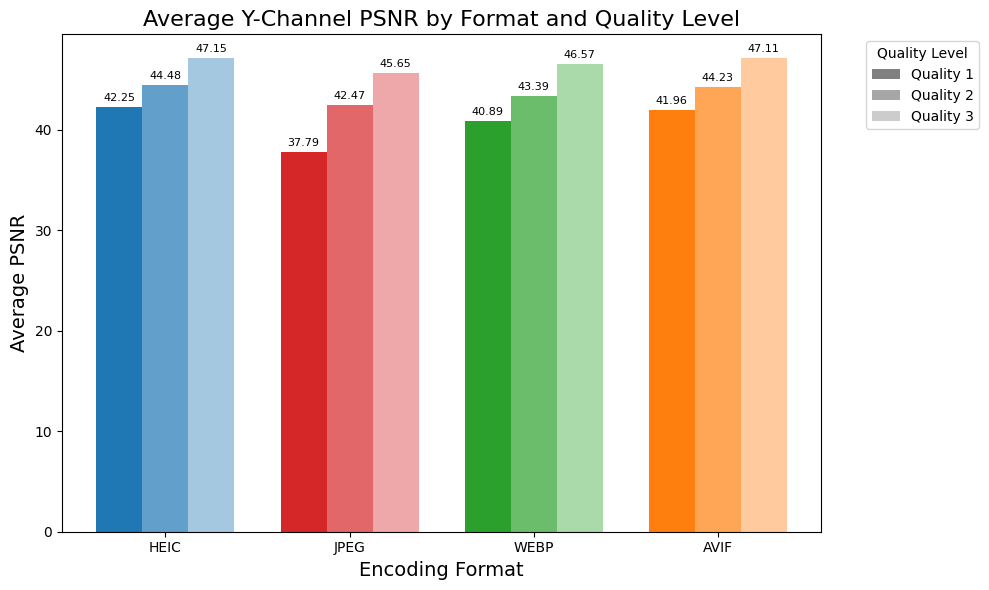

In [7]:
import numpy as np
from matplotlib.patches import Patch

## Calculate average Y_PSNR for each Format at each Quality Level
avg_psnr_df = df.groupby(['Quality_Level', 'Format'])['Y_PSNR'].mean().reset_index()

# 4. Get the unique quality levels
quality_levels = sorted(df['Quality_Level'].unique())

# Define the order of formats to ensure consistency across charts
format_order = ['HEIC', 'JPEG', 'WEBP', 'AVIF']

# 5. Create a single independent figure
plt.figure(figsize=(10, 6))

# X-axis positioning
x = np.arange(len(format_order))
width = 0.25

q1_vals, q2_vals, q3_vals, colors = [], [], [], []

# Extract PSNR and colors in the specified order for all three quality levels
for fmt in format_order:
    fmt_data = avg_psnr_df[avg_psnr_df['Format'] == fmt]
    
    # Extract data dynamically for the 3 quality levels
    q1_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[0]]['Y_PSNR'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[0]].empty else 0)
    q2_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[1]]['Y_PSNR'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[1]].empty else 0)
    q3_vals.append(fmt_data[fmt_data['Quality_Level'] == quality_levels[2]]['Y_PSNR'].values[0] if not fmt_data[fmt_data['Quality_Level'] == quality_levels[2]].empty else 0)
    
    colors.append(color_map.get(fmt, 'gray'))

# Create the triple gradient bar chart (same color, different transparency)
bars_q1 = plt.bar(x - width, q1_vals, width, color=colors, alpha=1.0)
bars_q2 = plt.bar(x, q2_vals, width, color=colors, alpha=0.7)
bars_q3 = plt.bar(x + width, q3_vals, width, color=colors, alpha=0.4)

# Formatting the plot
plt.title('Average Y-Channel PSNR by Format and Quality Level', fontsize=16)
plt.xlabel('Encoding Format', fontsize=14)
plt.ylabel('Average PSNR', fontsize=14)
plt.xticks(x, format_order)

# Add value labels on top of each bar for readability
for bars in [bars_q1, bars_q2, bars_q3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.annotate(f'{height:.2f}',
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom', fontsize=8)

# Custom legend for the Quality Levels placed OUTSIDE the plot
legend_elements = [
    Patch(facecolor='gray', alpha=1.0, label=f'Quality {quality_levels[0]}'),
    Patch(facecolor='gray', alpha=0.7, label=f'Quality {quality_levels[1]}'),
    Patch(facecolor='gray', alpha=0.4, label=f'Quality {quality_levels[2]}')
]
plt.legend(handles=legend_elements, title='Quality Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent clipping (especially for the outside legend)
plt.tight_layout()

# Save/Show the single figure
plt.show()

# Clear the current figure
plt.close()

In [8]:
# 1. Place the provided categories into a dictionary as data
categories = {
    "Macro": ["00007", "01556", "01718", "02633", "02637", "02642", "02645", "02651", "02655", "02662", "02666", "02672", "02679", "02680", "02686", "02725", "02757", "02758"],
    "Various": ["00090", "00623", "00730", "01254", "01255", "01256", "01575", "01576", "01595", "01646", "01648", "02268", "02269", "02316", "02344", "02435", "02447", "02452", "02558", "02622", "02623", "02695"],
    "Smooth": ["00001", "00374", "00731", "00732", "00733", "01558", "01559", "01881", "02219", "02220"],
    "Buildings": ["00609", "00635", "01263", "01497", "01498", "01501", "01506", "01518", "01526", "01820", "01831", "01967", "02150"],
    "Foliage": ["00053", "00562", "00632", "00633", "00792", "01082", "01087", "01088"],
    "Low light": ["00050", "00054", "00592", "00606", "01226", "01228", "01229", "01234", "01520", "01530", "01979", "02413"]
}

# 2. Flatten the dictionary for extremely fast reverse-lookups 
# This creates a map like: {'00007': 'Macro', '01556': 'Macro', ...}
num_to_category = {num: cat for cat, nums in categories.items() for num in nums}

# 3. Define the function to get the category
def assign_category(image_name):
    # Ensure it's a string and strip whitespace
    image_name = str(image_name).strip()
    
    # If it is a DSC image, grab the numbers and look up the category
    if image_name.startswith("DSC"):
        digits = image_name[3:] # Grab everything after 'DSC'
        return num_to_category.get(digits, "Uncategorized")
    
    # Optional: Automatically categorize your document files, or leave blank
    elif image_name.startswith("DOC"):
        return "Document"
    
    # Default fallback
    return ""

# 5. Create the new column
# Using insert() so the Category column sits at index 1 (right next to Original_Image)
##df.insert(1, 'Category', df['Original_Image'].apply(assign_category))

# 6. Save the new CSV
# (Feel free to add `sep=';'` if you still need it to open easily in European Excel)
## df.to_csv('unified_results_categorized.csv', index=False)

print("Finished categorizing the rows!")

Finished categorizing the rows!


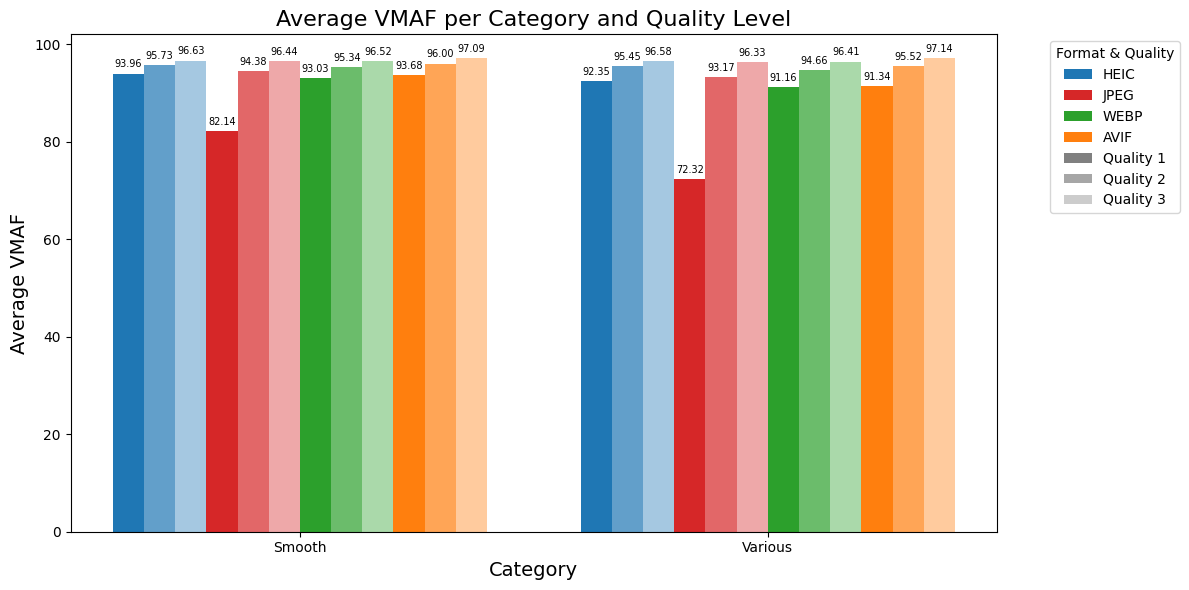

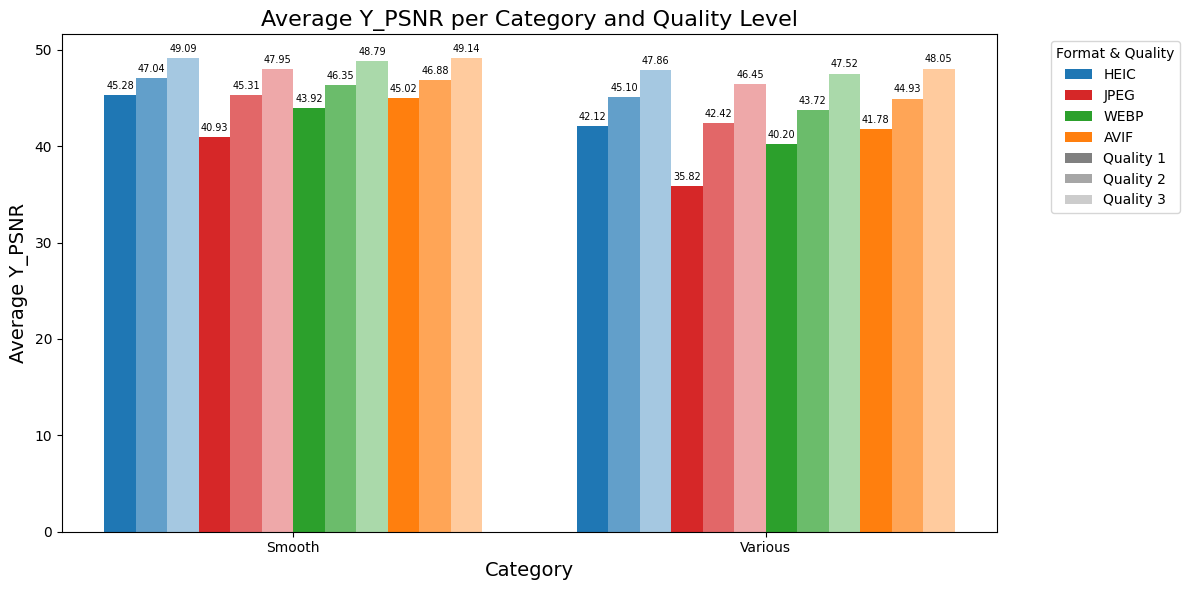

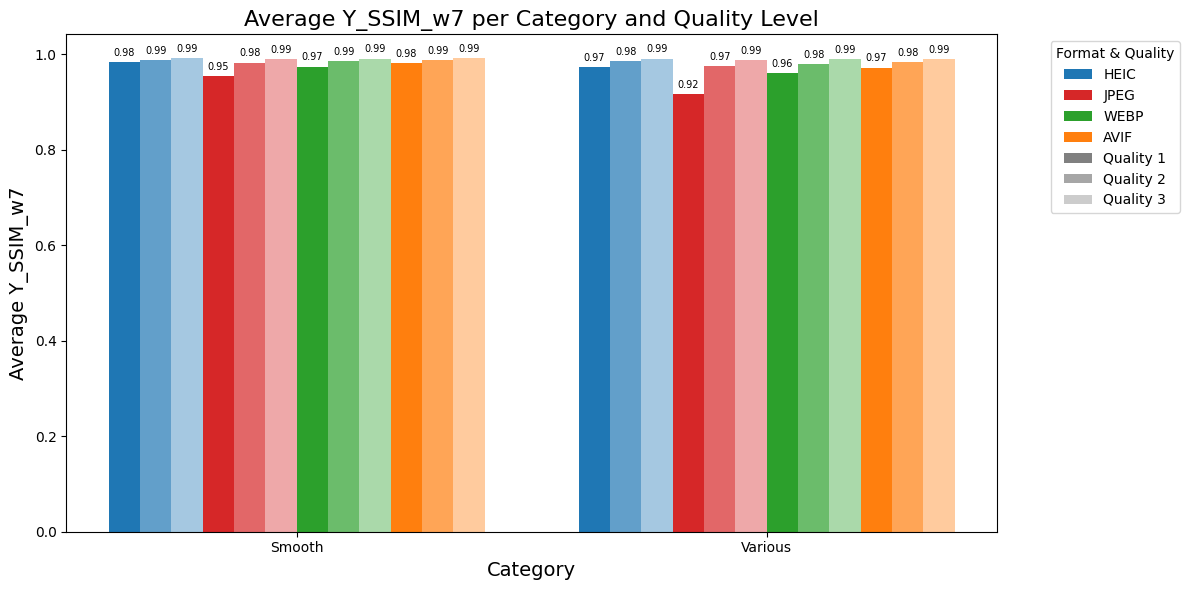

In [9]:
# Configuration
metrics = ['VMAF', 'Y_PSNR', 'Y_SSIM_w7']
categories = ['Smooth', 'Various']
format_order = ['HEIC', 'JPEG', 'WEBP', 'AVIF']

# 1. Filter the DataFrame to ONLY include 'Smooth' and 'Various' rows
filtered_df = df[df['Category'].isin(categories)]

# Group to calculate means for all required metrics at once
grouped_df = filtered_df.groupby(['Quality_Level', 'Category', 'Format'])[metrics].mean().reset_index()
quality_levels = sorted(grouped_df['Quality_Level'].dropna().unique())

# 2. Iterate through each Metric (Total = 3 charts instead of 9)
for metric in metrics:
    plt.figure(figsize=(12, 6))
    
    # X-axis will be the two categories
    x = np.arange(len(categories))  # Positions: 0 for Smooth, 1 for Various
    group_width = 0.2  # Total width allocated for each format
    bar_width = group_width / 3  # Width for each individual quality level bar
    
    # Offsets to center the 4 format groups cleanly over the category label
    offsets = [-1.5 * group_width, -0.5 * group_width, 0.5 * group_width, 1.5 * group_width]
    
    format_handles = [] # To store legend info for formats
    
    # 3. Plot a group of 3 bars for each format across the categories
    for i, fmt in enumerate(format_order):
        q1_vals, q2_vals, q3_vals = [], [], []
        
        # Extract data for Smooth, then for Various
        for cat in categories:
            # Get data for each quality level
            row_q1 = grouped_df[(grouped_df['Category'] == cat) & (grouped_df['Format'] == fmt) & (grouped_df['Quality_Level'] == quality_levels[0])]
            row_q2 = grouped_df[(grouped_df['Category'] == cat) & (grouped_df['Format'] == fmt) & (grouped_df['Quality_Level'] == quality_levels[1])]
            row_q3 = grouped_df[(grouped_df['Category'] == cat) & (grouped_df['Format'] == fmt) & (grouped_df['Quality_Level'] == quality_levels[2])]
            
            q1_vals.append(row_q1[metric].values[0] if not row_q1.empty else 0)
            q2_vals.append(row_q2[metric].values[0] if not row_q2.empty else 0)
            q3_vals.append(row_q3[metric].values[0] if not row_q3.empty else 0)
        
        color = color_map.get(fmt, 'gray')
        base_x = x + offsets[i]
        
        # Plot the 3 sub-bars using the triple gradient alpha
        bars_q1 = plt.bar(base_x - bar_width, q1_vals, bar_width, color=color, alpha=1.0)
        bars_q2 = plt.bar(base_x,             q2_vals, bar_width, color=color, alpha=0.7)
        bars_q3 = plt.bar(base_x + bar_width, q3_vals, bar_width, color=color, alpha=0.4)
        
        # Add to format handles for the legend
        format_handles.append(Patch(facecolor=color, label=fmt))
        
        # Add annotations
        for bars in [bars_q1, bars_q2, bars_q3]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    plt.annotate(f'{height:.2f}',
                                 xy=(bar.get_x() + bar.get_width() / 2, height),
                                 xytext=(0, 3), textcoords="offset points",
                                 ha='center', va='bottom', fontsize=7) # Slightly smaller font to fit them all
    
    # 4. Formatting
    plt.title(f'Average {metric} per Category and Quality Level', fontsize=16)
    plt.xlabel('Category', fontsize=14)
    plt.ylabel(f'Average {metric}', fontsize=14)
    plt.xticks(x, categories) 
    
    # Custom legend for BOTH formats and quality levels, placed outside
    quality_handles = [
        Patch(facecolor='gray', alpha=1.0, label=f'Quality {quality_levels[0]}'),
        Patch(facecolor='gray', alpha=0.7, label=f'Quality {quality_levels[1]}'),
        Patch(facecolor='gray', alpha=0.4, label=f'Quality {quality_levels[2]}')
    ]
    plt.legend(handles=format_handles + quality_handles, title='Format & Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ensure the layout adjusts to fit the external legend
    plt.tight_layout()
    plt.show()
    plt.close()